# Laptop Pricing: Model Evaluation & Refinement

This project demonstrates how regression models can be evaluated and improved to predict laptop prices.

## Techniques Used
- Train/test split
- Linear regression
- Cross-validation
- Polynomial regression
- Ridge regression (regularization)
- Hyperparameter tuning with GridSearchCV

In [1]:
import pandas as pd

df = pd.read_csv("laptop_pricing_dataset_mod2.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [3]:
df.shape
df.columns

Index(['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch',
       'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_pounds', 'Price',
       'Price-binned', 'Screen-Full_HD', 'Screen-IPS_panel'],
      dtype='object')

In [4]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True, errors='ignore')

In [5]:
# Remove unnecessary index columns if they exist
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True, errors='ignore')

# Confirm the dataset after cleanup
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [6]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Check column names
df.columns

Dataset shape: (238, 14)


Index(['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch',
       'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_pounds', 'Price',
       'Price-binned', 'Screen-Full_HD', 'Screen-IPS_panel'],
      dtype='object')

## Task 1: Using Cross-Validation to Improve the Model

First, I will separate the dataset into input features and the target variable.

The target variable is `Price`, because the goal is to predict laptop prices.

In [7]:
# Define the target variable
y_data = df['Price']

# Define the input features
x_data = df.drop('Price', axis=1)

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.10,
    random_state=1
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 214
Testing samples: 24


## Simple Linear Regression

Now I will create a simple linear regression model using `CPU_frequency` to predict `Price`.

In [9]:
from sklearn.linear_model import LinearRegression

# Create a linear regression object
lre = LinearRegression()

# Train the model using CPU_frequency
lre.fit(x_train[['CPU_frequency']], y_train)

# Calculate R-squared for training and testing data
print("Training R-squared:", lre.score(x_train[['CPU_frequency']], y_train))
print("Testing R-squared:", lre.score(x_test[['CPU_frequency']], y_test))

Training R-squared: 0.14829792099817973
Testing R-squared: -0.06599437350393789


## Cross-Validation

Cross-validation gives a more reliable estimate of model performance because it tests the model across multiple splits of the data.

In [10]:
from sklearn.model_selection import cross_val_score

# Run 4-fold cross-validation
Rcross = cross_val_score(lre, x_data[['CPU_frequency']], y_data, cv=4)

print("Cross-validation scores:", Rcross)
print("Mean R-squared:", Rcross.mean())
print("Standard deviation:", Rcross.std())

Cross-validation scores: [-0.82012763  0.10035872  0.11202939 -0.03662978]
Mean R-squared: -0.16109232388595113
Standard deviation: 0.384957978666471


## Task 2: Overfitting

In this section, I will test polynomial regression models with different degrees.

Higher-degree polynomial models can sometimes fit the training data better, but they may also overfit and perform worse on test data.

In [11]:
# Split the data again, this time using 50% for testing
x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.50,
    random_state=0
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 119
Testing samples: 119


In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np

# Store R-squared values
Rsqu_test = []

# Test polynomial degrees from 1 to 5
orders = [1, 2, 3, 4, 5]

for n in orders:
    pr = PolynomialFeatures(degree=n)

    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr = pr.transform(x_test[['CPU_frequency']])

    lr = LinearRegression()
    lr.fit(x_train_pr, y_train)

    yhat = lr.predict(x_test_pr)

    Rsqu_test.append(r2_score(y_test, yhat))

Rsqu_test

[0.05322174176198102,
 -0.026920818678998204,
 0.051563457925576706,
 -0.9948137915475526,
 -1.3759360956325843]

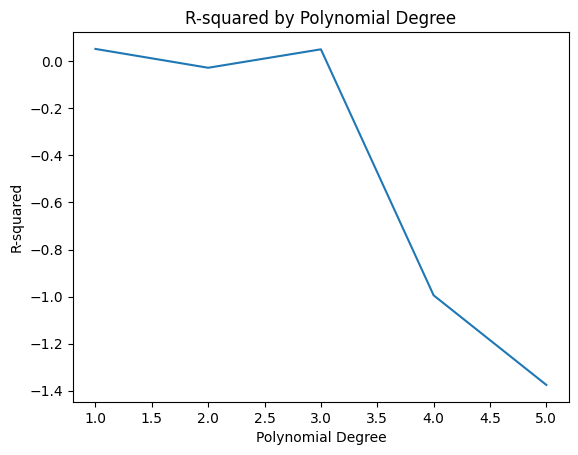

In [13]:
import matplotlib.pyplot as plt

plt.plot(orders, Rsqu_test)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("R-squared by Polynomial Degree")
plt.show()

### Interpretation

The best polynomial degree is the one with the highest R-squared score on the test data.

If the R-squared score drops as the degree increases, that suggests the model is overfitting.

## Task 3: Ridge Regression

Ridge Regression helps reduce overfitting by adding regularization.

The alpha value controls the strength of regularization:
- Lower alpha = less regularization
- Higher alpha = more regularization

In [14]:
from sklearn.linear_model import Ridge

# Features listed in the lab
features = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']

# Create polynomial features with degree 2
pr = PolynomialFeatures(degree=2)

x_train_pr = pr.fit_transform(x_train[features])
x_test_pr = pr.transform(x_test[features])

print("Polynomial training shape:", x_train_pr.shape)
print("Polynomial testing shape:", x_test_pr.shape)

Polynomial training shape: (119, 36)
Polynomial testing shape: (119, 36)


In [15]:
# Test different alpha values
alphas = np.arange(0.001, 1, 0.001)

r2_train = []
r2_test = []

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(x_train_pr, y_train)

    r2_train.append(ridge_model.score(x_train_pr, y_train))
    r2_test.append(ridge_model.score(x_test_pr, y_test))

print("Best test R-squared:", max(r2_test))
print("Best alpha:", alphas[r2_test.index(max(r2_test))])

Best test R-squared: 0.4239063186850006
Best alpha: 0.007


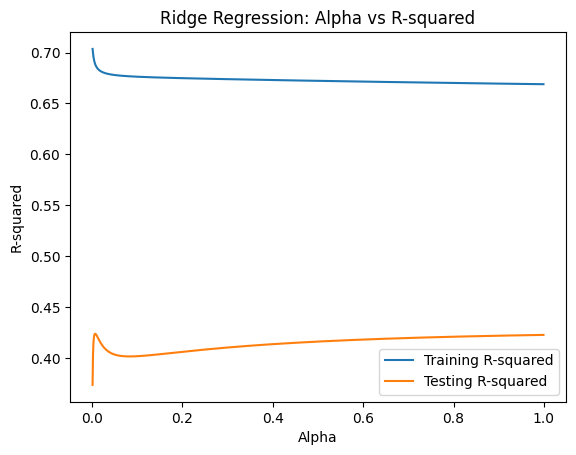

In [16]:
plt.plot(alphas, r2_train, label="Training R-squared")
plt.plot(alphas, r2_test, label="Testing R-squared")
plt.xlabel("Alpha")
plt.ylabel("R-squared")
plt.title("Ridge Regression: Alpha vs R-squared")
plt.legend()
plt.show()

## Task 4: Grid Search

GridSearchCV automatically tests different alpha values and selects the best one based on cross-validation.

In [17]:
from sklearn.model_selection import GridSearchCV

# Alpha values from the lab
parameters = [{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}]

# Create Ridge model
RR = Ridge()

# Create GridSearchCV object
Grid1 = GridSearchCV(RR, parameters, cv=4)

In [18]:
# Fit GridSearchCV using all selected features
Grid1.fit(x_data[features], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}])

In [19]:
# Show the best model
BestRR = Grid1.best_estimator_

BestRR

Ridge(alpha=0.0001)

In [20]:
# Evaluate the best Ridge model on the test data
BestRR.score(x_test[features], y_test)

0.4412383966156085

## Summary

In this project, I evaluated and refined regression models to improve laptop price predictions.

### Techniques Applied
- Train/test split to evaluate model performance  
- Linear regression using CPU frequency  
- Cross-validation for more reliable performance estimates  
- Polynomial regression to explore model complexity  
- Ridge regression to reduce overfitting  
- GridSearchCV to identify the optimal alpha value  

### Key Insight
The most complex model does not always perform best. Models that generalize well to unseen data provide more reliable predictions than those that only fit training data.

### Key Outcome
Identified the optimal model complexity and regularization parameter (alpha) to improve generalization and reduce overfitting.

### Tools
Python, Pandas, Scikit-learn, Matplotlib